key: a (s1, s3) = ( -0.1333333333333332 , 7.248065843621399 ) (q1, q3) = ( 0.0 , -32.00000000000007 )
key: b (s1, s3) = ( -0.2666666666666669 , -5.478189300411507 ) (q1, q3) = ( 0.0 , -32.00000000000007 )
key: c (s1, s3) = ( -0.08888888888888893 , -0.08427983539094441 ) (q1, q3) = ( 0.0 , -32.00000000000007 )
key: d (s1, s3) = ( -0.533333333333333 , 3.286913580246914 ) (q1, q3) = ( 0.0 , -32.00000000000007 )


Center = ( 3.286913580246914 , 0.0 ) Radius = 0.533333333333333


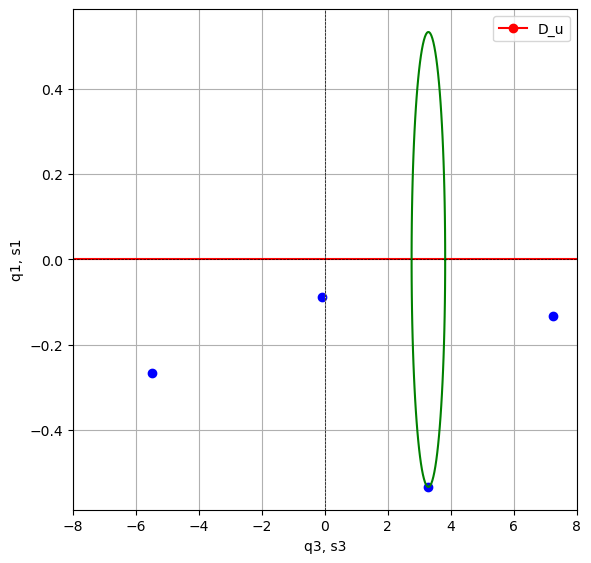

In [1]:
from   scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np
import math

m       =  225   # Масса [кг]
I22     =  12.5  # Момент инерции [кг*м^2]
T       =  20    # Длительность этапа для обезразмеривания [с]
L       =  1     # Длина для обезразмеривания [м]
fz3_max =  4     # Максимальная тяга боковых двигателей [Н]

fz1 = [20 * T**2 / (m * L), 0, -20 * T**2/ (m * L)]  # [Н] разгон, дрейф, торможение
u   = (fz3_max * T**2) / (m * L)

perturbations = {
    'a': {'deltaM1z2':  0.007, 'deltaM3z2': -0.005, 'deltaf1z1':  0.03, 'deltaf3z1': -0.3},
    'b': {'deltaM1z2': -0.005, 'deltaM3z2':  0.0,   'deltaf1z1': -0.02, 'deltaf3z1': -0.2},
    'c': {'deltaM1z2':  0.003, 'deltaM3z2': -0.04,  'deltaf1z1': -0.02, 'deltaf3z1':  0.0},
    'd': {'deltaM1z2':  0.003, 'deltaM3z2':  0.0,   'deltaf1z1': -0.02, 'deltaf3z1': -0.5},
}

# Задаем систему для переменных q
def q_system(t, y, fz1):
    q1, q2, q3, q4, q5, q6 = y
    up = (fz1 * T**2) / (m * L)

    dqdt = [q2, 0, q4, -u - q5 * up, q6, 0]

    return dqdt
    
# Решаем систему для q
def q_solve(fz1):
    initial_conditions = [0, 0, 0, 0, 0, 0]

    stage1 = solve_ivp(q_system, [0, 1], initial_conditions, t_eval=np.linspace(0, 1, 100), args = (fz1[0],))
    stage1_end = stage1.y[:, -1]

    stage2 = solve_ivp(q_system, [1, 2], stage1_end, t_eval=np.linspace(1, 2, 100), args = (fz1[1],))
    stage2_end = stage2.y[:, -1]

    stage3 = solve_ivp(q_system, [2, 3], stage2_end, t_eval=np.linspace(2, 3, 100), args = (fz1[2],))
    stage3_end = stage3.y[:, -1]
    
    return stage1, stage2, stage3, stage3_end

# Задаем систему для переменных s
def s_system(t, y, fz1, deltafz1, deltaMz2):
    s1, s2, s3, s4, s5, s6 = y
    up = (fz1 * T**2) / (m * L)
    vz1 = (deltafz1 * T**2) / (m * L)
    vz2 = (deltaMz2 * T**2) / I22

    dsdt = [s2, vz1, s4, -s5 * up, s6, vz2]

    return dsdt

# Решаем систему для s
def s_solve(fz1, perturbation):
    initial_conditions = [0, 0, 0, 0, 0, 0]

    stage1 = solve_ivp(s_system, [0, 1], initial_conditions, 
                       t_eval=np.linspace(0, 1, 100), args = (fz1[0], perturbation['deltaf1z1'], perturbation['deltaM1z2']))
    stage1_end = stage1.y[:, -1]

    stage2 = solve_ivp(s_system, [1, 2], stage1_end, 
                       t_eval=np.linspace(1, 2, 100), args = (fz1[1], 0, 0))
    stage2_end = stage2.y[:, -1]

    stage3 = solve_ivp(s_system, [2, 3], stage2_end, 
                       t_eval=np.linspace(2, 3, 100), args = (fz1[2], perturbation['deltaf3z1'], perturbation['deltaM3z2']))
    stage3_end = stage3.y[:, -1]
    
    return stage1, stage2, stage3, stage3_end

# Функция ищет расстояние от точки px, py до отрезка (x1,y1) (x2, y2)
def distance(px, py, x1, y1, x2, y2):
    AB = np.array([x2 - x1, y2 - y1])  
    AP = np.array([px - x1, py - y1])  
    BP = np.array([px - x2, py - y2])  
  
    AB_len_squared = AB.dot(AB)
    
    if AB_len_squared == 0:
        return np.linalg.norm(AP), x1, y1  
    
    t = AB.dot(AP) / AB_len_squared
    
    if t < 0:
        return np.linalg.norm(AP), x1, y1
    elif t > 1:  
        return np.linalg.norm(BP), x2, y2
    
    projection = np.array([x1, y1]) + t * AB
    
    return np.linalg.norm(np.array([px, py]) - projection), projection[0], projection[1] # возвращаем расстояние и координаты проекции

results    = {}   # Результаты решения системы по режимам и случаям
q1_key     = []   # Список q1 в зависимости от случая
q3_key     = []   # Список q3 в зависимости от случая
s1         = []   # Список s1 по случаям 
s3         = []   # Список s3 по случаям 
distances  = []   # Расстояния от точек D_w до отрезка D_u

for key, perturbation in perturbations.items():
    stage1_q, stage2_q, stage3_q, q_tau = q_solve(fz1)
    stage1_s, stage2_s, stage3_s, s_tau = s_solve(fz1, perturbation)

    results[key] = {'stage1_q': stage1_q,'stage2_q': stage2_q,'stage3_q': stage3_q,
                    'stage1_s': stage1_s,'stage2_s': stage2_s,'stage3_s': stage3_s}

    print (f'key: {key} (s1, s3) = (', s_tau[0], ',', s_tau[2], ')', '(q1, q3) = (', q_tau[0], ',', q_tau[2], ')')

    q1_key.append(abs(q_tau[0]))
    q3_key.append(abs(q_tau[2]))

    s1.append(s_tau[0])
    s3.append(s_tau[2])

q1 = max(q1_key) # = 0 
q3 = max(q3_key) # концы отрезка

coord1 = [] # запоминаем координаты точек, от которых считается расстояние до (s1, s3), чтобы потом найти точки для максимума 
coord2 = []

# Заполняем радиусы и точки 
for i in range(4):
    r, c1, c2 = distance(s3[i], s1[i], q3, 0, -q3, 0)
    distances.append(r)
    coord1.append(c1)
    coord2.append(c2)


radius = max(distances)           # Максимальное расстояние от отрезка, D_u, до элемента из D_w 
index  = distances.index(radius)  # Индекс максимального расстояния
x_c    = coord1[index]            # x - координата центра окружности
y_c    = coord2[index]            # y - координата центра окружности

print ('\n')
print ('Center = (', x_c, ',', y_c, ')', 'Radius =', radius)

#--------------------------------------------------------Рисунок--------------------------------------------------------------------------

plt.figure(figsize = (6.5, 6.5)) 

plt.plot([q3, -q3], [0, 0], 'ro-', label = f'D_u')  # D_u - отрезок

for i in range(4):
    plt.scatter(s3[i], s1[i], color = 'blue')       # Элементы множества D_w (s3 по x, s1 по y)

theta = np.linspace(0, 2 * np.pi, 100)              # Задаем угол для окружности 
x     = x_c + radius * np.cos(theta)                # x - координата окружности 
y     = y_c + radius * np.sin(theta)                # y - координата окружности 
plt.plot(x, y, color = 'green')

plt.xlim    (-8, 8)
#plt.ylim    (-4, 4)
plt.axhline (0, color = 'black', linewidth = 0.5, linestyle = '--')
plt.axvline (0, color = 'black', linewidth = 0.5, linestyle = '--')
plt.xlabel  ('q3, s3')
plt.ylabel  ('q1, s1')
plt.legend  ()
plt.grid    (True)

plt.show()
